# Data Quality Diagnostics Notebook
**Group 10 | nvd-snow-yolov9**

This notebook objectively diagnoses data quality issues — particularly the train/val vs test distribution mismatch.

### Objectives
1. **Label sanity** — Are labels valid YOLO format? Any empty/corrupt files?
2. **Image sanity** — Corrupt images, resolution consistency, channel issues
3. **Class distribution** — Are bboxes present and reasonably distributed across splits?
4. **Visual spot-check** — Show sample images with overlaid bboxes for each split
5. **Train/Val/Test distribution comparison** — Image statistics (brightness, contrast) to detect domain shift
6. **Test set deep-dive** — Why is test mAP ~0? Check if labels exist, if images are valid
7. **Prediction vs GT overlay** — Load best.pt and visualize what the model actually predicts on test images

In [1]:
import os
from pathlib import Path

# Walk up from the notebook's cwd to find the project root (has config.yaml).
p = Path.cwd()
while not (p / 'config.yaml').exists() and p != p.parent:
    p = p.parent
os.chdir(p)
print(f'CWD: {os.getcwd()}')

CWD: C:\Users\achku\Documents\Applied AI\courses\D7047E Advanced Deep Learning\Project\project\project


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
import json

# Dataset roots (project-root-relative; cell 1 chdir'd us there)
YOLO_ROOT  = Path('outputs/yolo')
IMG_ROOT   = YOLO_ROOT / 'images'
LBL_ROOT   = YOLO_ROOT / 'labels'
RESULTS_DIR = Path('outputs/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SPLITS     = ['train', 'val', 'test']

print('Paths:')
for s in SPLITS:
    n_img = len(list((IMG_ROOT / s).glob('*.png')) + list((IMG_ROOT / s).glob('*.jpg')))
    n_lbl = len(list((LBL_ROOT / s).glob('*.txt')))
    print(f'  {s:5s}: {n_img:5d} images | {n_lbl:5d} label files')

Paths:
  train:  6056 images |  6056 label files
  val  :  1203 images |  1203 label files
  test :  1191 images |  1191 label files


## 1. Label Sanity Check
YOLO labels must be: `class cx cy w h` all in [0,1]. Any deviation = broken data.

In [3]:
def check_labels(split):
    lbl_dir = LBL_ROOT / split
    img_dir = IMG_ROOT / split
    
    stats = {
        'total_label_files': 0,
        'empty_label_files': 0,         # files with 0 annotations
        'missing_label_files': 0,       # images with no .txt pair
        'corrupt_label_files': 0,       # malformed rows
        'out_of_range_coords': 0,       # cx/cy/w/h outside [0,1]
        'negative_dims': 0,             # w or h <= 0
        'total_annotations': 0,
        'bad_files': []                 # list of problem files
    }
    
    images = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    
    for img_path in images:
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        
        if not lbl_path.exists():
            stats['missing_label_files'] += 1
            stats['bad_files'].append(f'MISSING_LABEL: {img_path.name}')
            continue
        
        stats['total_label_files'] += 1
        lines = lbl_path.read_text().strip().splitlines()
        
        if len(lines) == 0:
            stats['empty_label_files'] += 1
            continue
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                stats['corrupt_label_files'] += 1
                stats['bad_files'].append(f'CORRUPT_ROW: {lbl_path.name} → "{line}"')
                break
            try:
                cls, cx, cy, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                stats['total_annotations'] += 1
                
                # Check range
                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    stats['out_of_range_coords'] += 1
                    if len(stats['bad_files']) < 20:
                        stats['bad_files'].append(f'OUT_OF_RANGE: {lbl_path.name} → cx={cx:.3f} cy={cy:.3f} w={w:.3f} h={h:.3f}')
                
                if w <= 0 or h <= 0:
                    stats['negative_dims'] += 1
            except ValueError:
                stats['corrupt_label_files'] += 1
                stats['bad_files'].append(f'PARSE_ERROR: {lbl_path.name}')
    
    return stats


print('=' * 65)
print(f'LABEL SANITY CHECK')
print('=' * 65)

all_stats = {}
for split in SPLITS:
    s = check_labels(split)
    all_stats[split] = s
    print(f'\n[{split.upper()}]')
    print(f'  Label files         : {s["total_label_files"]}')
    print(f'  Total annotations   : {s["total_annotations"]}')
    print(f'  Empty label files   : {s["empty_label_files"]}  ← should be 0 or expected background')
    print(f'  Missing label files : {s["missing_label_files"]}  ← PROBLEM if > 0')
    print(f'  Corrupt rows        : {s["corrupt_label_files"]}  ← PROBLEM if > 0')
    print(f'  Out-of-range coords : {s["out_of_range_coords"]}  ← PROBLEM if > 0')
    print(f'  Negative dims       : {s["negative_dims"]}  ← PROBLEM if > 0')
    if s['bad_files']:
        print(f'  ⚠ First bad entries:')
        for bf in s['bad_files'][:5]:
            print(f'    {bf}')

print('\n' + '=' * 65)

LABEL SANITY CHECK



[TRAIN]
  Label files         : 6056
  Total annotations   : 18956
  Empty label files   : 0  ← should be 0 or expected background
  Missing label files : 0  ← PROBLEM if > 0
  Corrupt rows        : 0  ← PROBLEM if > 0
  Out-of-range coords : 0  ← PROBLEM if > 0
  Negative dims       : 0  ← PROBLEM if > 0



[VAL]
  Label files         : 1203
  Total annotations   : 4168
  Empty label files   : 0  ← should be 0 or expected background
  Missing label files : 0  ← PROBLEM if > 0
  Corrupt rows        : 0  ← PROBLEM if > 0
  Out-of-range coords : 0  ← PROBLEM if > 0
  Negative dims       : 0  ← PROBLEM if > 0



[TEST]
  Label files         : 1191
  Total annotations   : 3169
  Empty label files   : 0  ← should be 0 or expected background
  Missing label files : 0  ← PROBLEM if > 0
  Corrupt rows        : 0  ← PROBLEM if > 0
  Out-of-range coords : 0  ← PROBLEM if > 0
  Negative dims       : 0  ← PROBLEM if > 0



## 2. Image Sanity Check
Check for corrupt images, inconsistent sizes, and grayscale vs RGB issues.

In [4]:
def check_images(split, sample_n=200):
    img_dir = IMG_ROOT / split
    images  = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    
    # Sample if too many
    if len(images) > sample_n:
        rng = np.random.default_rng(42)
        images = list(rng.choice(images, sample_n, replace=False))
    
    stats = {
        'total': len(images),
        'corrupt': 0,
        'truncated': 0,
        'sizes': [],
        'channels': defaultdict(int),
        'mean_brightness': [],
        'mean_contrast': [],
        'bad_files': []
    }
    
    for p in images:
        img = cv2.imread(str(p))
        if img is None:
            stats['corrupt'] += 1
            stats['bad_files'].append(f'UNREADABLE: {p.name}')
            continue
        
        h, w = img.shape[:2]
        c = img.shape[2] if img.ndim == 3 else 1
        
        if h < 32 or w < 32:
            stats['truncated'] += 1
            stats['bad_files'].append(f'TINY({w}x{h}): {p.name}')
        
        stats['sizes'].append((w, h))
        stats['channels'][c] += 1
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)
        stats['mean_brightness'].append(gray.mean())
        stats['mean_contrast'].append(gray.std())
    
    return stats


print('IMAGE SANITY CHECK (sampled 200 per split)')
print('=' * 65)

img_stats = {}
for split in SPLITS:
    s = check_images(split)
    img_stats[split] = s
    sizes = s['sizes']
    widths  = [sz[0] for sz in sizes]
    heights = [sz[1] for sz in sizes]
    
    print(f'\n[{split.upper()}]')
    print(f'  Sampled             : {s["total"]}')
    print(f'  Corrupt (unreadable): {s["corrupt"]}  ← PROBLEM if > 0')
    print(f'  Tiny images (<32px) : {s["truncated"]}  ← PROBLEM if > 0')
    if widths:
        print(f'  Width  range        : {min(widths)} – {max(widths)} px  (median {int(np.median(widths))})')
        print(f'  Height range        : {min(heights)} – {max(heights)} px  (median {int(np.median(heights))})')
    print(f'  Channels            : {dict(s["channels"])}')
    if s['mean_brightness']:
        print(f'  Brightness  mean±std: {np.mean(s["mean_brightness"]):.1f} ± {np.std(s["mean_brightness"]):.1f}  (range: {np.min(s["mean_brightness"]):.1f}–{np.max(s["mean_brightness"]):.1f})')
        print(f'  Contrast    mean±std: {np.mean(s["mean_contrast"]):.1f} ± {np.std(s["mean_contrast"]):.1f}')
    if s['bad_files']:
        print(f'  ⚠ Bad files (first 5):')
        for bf in s['bad_files'][:5]:
            print(f'    {bf}')

print('\n' + '=' * 65)

IMAGE SANITY CHECK (sampled 200 per split)



[TRAIN]
  Sampled             : 200
  Corrupt (unreadable): 0  ← PROBLEM if > 0
  Tiny images (<32px) : 0  ← PROBLEM if > 0
  Width  range        : 1920 – 1920 px  (median 1920)
  Height range        : 1080 – 1080 px  (median 1080)
  Channels            : {3: 200}
  Brightness  mean±std: 103.4 ± 23.0  (range: 18.9–139.0)
  Contrast    mean±std: 52.5 ± 7.0



[VAL]
  Sampled             : 200
  Corrupt (unreadable): 0  ← PROBLEM if > 0
  Tiny images (<32px) : 0  ← PROBLEM if > 0
  Width  range        : 1920 – 1920 px  (median 1920)
  Height range        : 1080 – 1080 px  (median 1080)
  Channels            : {3: 200}
  Brightness  mean±std: 95.4 ± 12.3  (range: 52.6–121.2)
  Contrast    mean±std: 63.8 ± 6.4



[TEST]
  Sampled             : 200
  Corrupt (unreadable): 0  ← PROBLEM if > 0
  Tiny images (<32px) : 0  ← PROBLEM if > 0
  Width  range        : 1920 – 1920 px  (median 1920)
  Height range        : 1080 – 1080 px  (median 1080)
  Channels            : {3: 200}
  Brightness  mean±std: 77.3 ± 13.3  (range: 22.8–105.7)
  Contrast    mean±std: 49.4 ± 5.6



## 3. Distribution Comparison Plot
Compare brightness and contrast distributions across train/val/test. If test looks very different from train → domain shift.

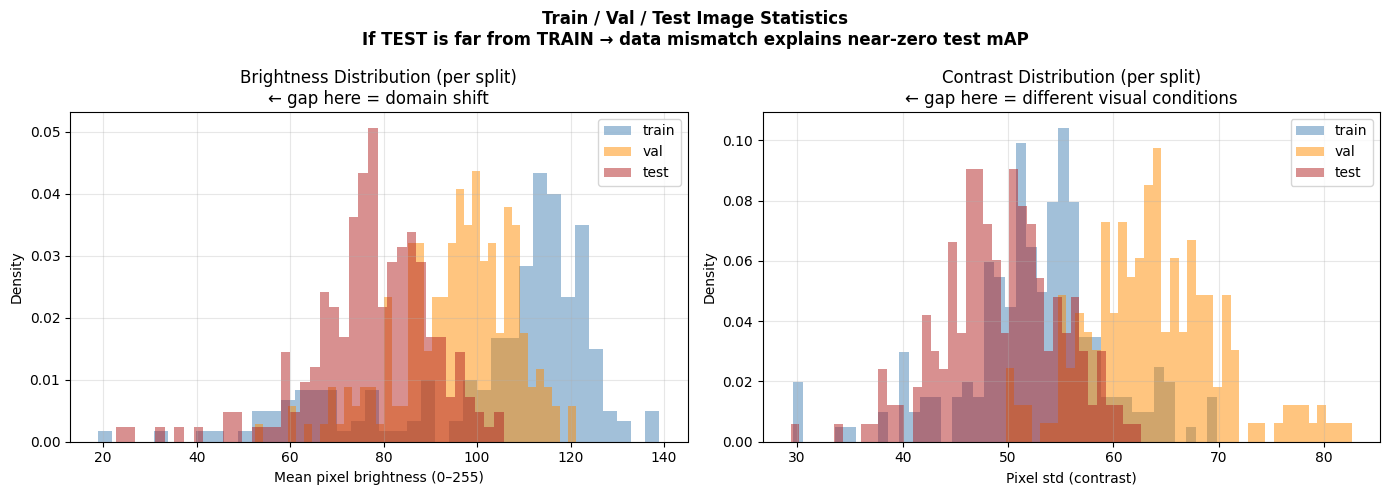

Saved: outputs\results\diag_brightness_contrast.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'train': 'steelblue', 'val': 'darkorange', 'test': 'firebrick'}

for split in SPLITS:
    s = img_stats[split]
    if s['mean_brightness']:
        axes[0].hist(s['mean_brightness'], bins=40, alpha=0.5, color=colors[split], label=split, density=True)
        axes[1].hist(s['mean_contrast'],   bins=40, alpha=0.5, color=colors[split], label=split, density=True)

axes[0].set_title('Brightness Distribution (per split)\n← gap here = domain shift')
axes[0].set_xlabel('Mean pixel brightness (0–255)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Contrast Distribution (per split)\n← gap here = different visual conditions')
axes[1].set_xlabel('Pixel std (contrast)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Train / Val / Test Image Statistics\n'
             'If TEST is far from TRAIN → data mismatch explains near-zero test mAP',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'diag_brightness_contrast.png'), dpi=120)
plt.show()
print(f'Saved: {RESULTS_DIR / "diag_brightness_contrast.png"}')

## 4. Annotation Density Per Split
How many bboxes per image? If test has very different density → label mismatch.

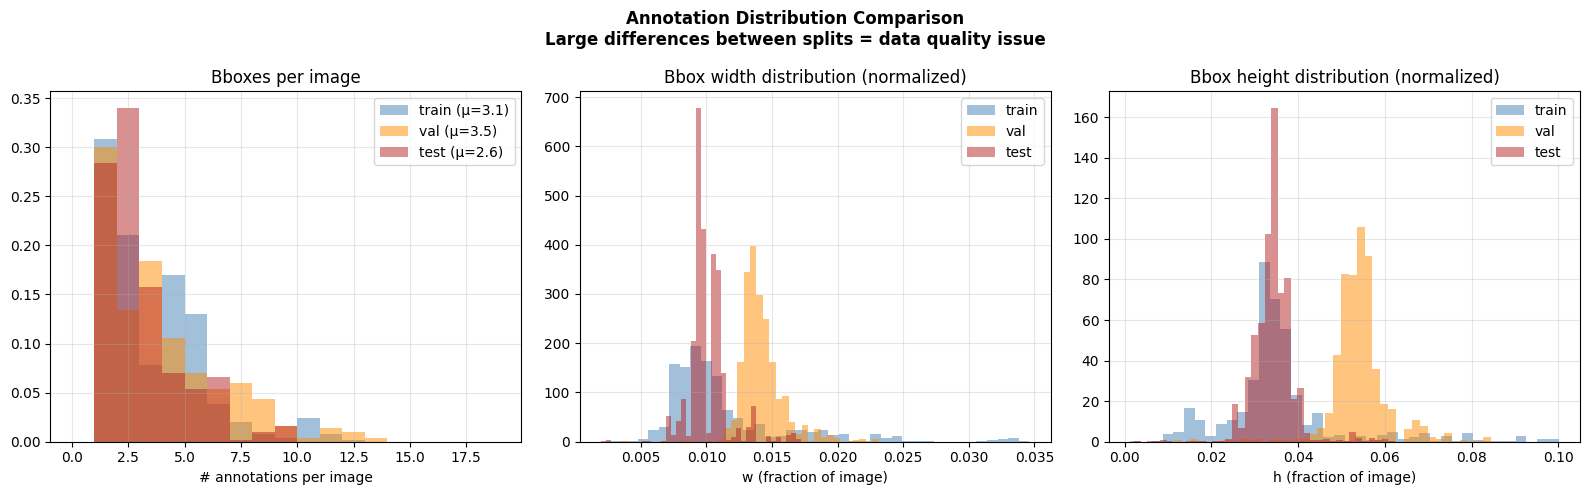

Saved: outputs\results\diag_bbox_distribution.png


In [6]:
def get_bbox_counts(split, max_files=500):
    lbl_dir = LBL_ROOT / split
    files = list(lbl_dir.glob('*.txt'))
    if len(files) > max_files:
        rng = np.random.default_rng(42)
        files = list(rng.choice(files, max_files, replace=False))
    
    counts = []
    box_widths  = []
    box_heights = []
    
    for f in files:
        lines = f.read_text().strip().splitlines()
        valid = [l for l in lines if len(l.strip().split()) == 5]
        counts.append(len(valid))
        for l in valid:
            try:
                _, cx, cy, w, h = l.strip().split()
                box_widths.append(float(w))
                box_heights.append(float(h))
            except:
                pass
    
    return counts, box_widths, box_heights


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for split in SPLITS:
    counts, bw, bh = get_bbox_counts(split)
    color = colors[split]
    
    axes[0].hist(counts, bins=range(0, 20), alpha=0.5, color=color, label=f'{split} (μ={np.mean(counts):.1f})', density=True)
    if bw:
        axes[1].hist(bw, bins=40, alpha=0.5, color=color, label=split, density=True)
        axes[2].hist(bh, bins=40, alpha=0.5, color=color, label=split, density=True)

axes[0].set_title('Bboxes per image')
axes[0].set_xlabel('# annotations per image')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Bbox width distribution (normalized)')
axes[1].set_xlabel('w (fraction of image)')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].set_title('Bbox height distribution (normalized)')
axes[2].set_xlabel('h (fraction of image)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Annotation Distribution Comparison\nLarge differences between splits = data quality issue',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'diag_bbox_distribution.png'), dpi=120)
plt.show()
print(f'Saved: {RESULTS_DIR / "diag_bbox_distribution.png"}')

## 5. Visual Spot-Check — Sample Images with GT Boxes
Visually inspect ground-truth labels overlaid on images for each split.

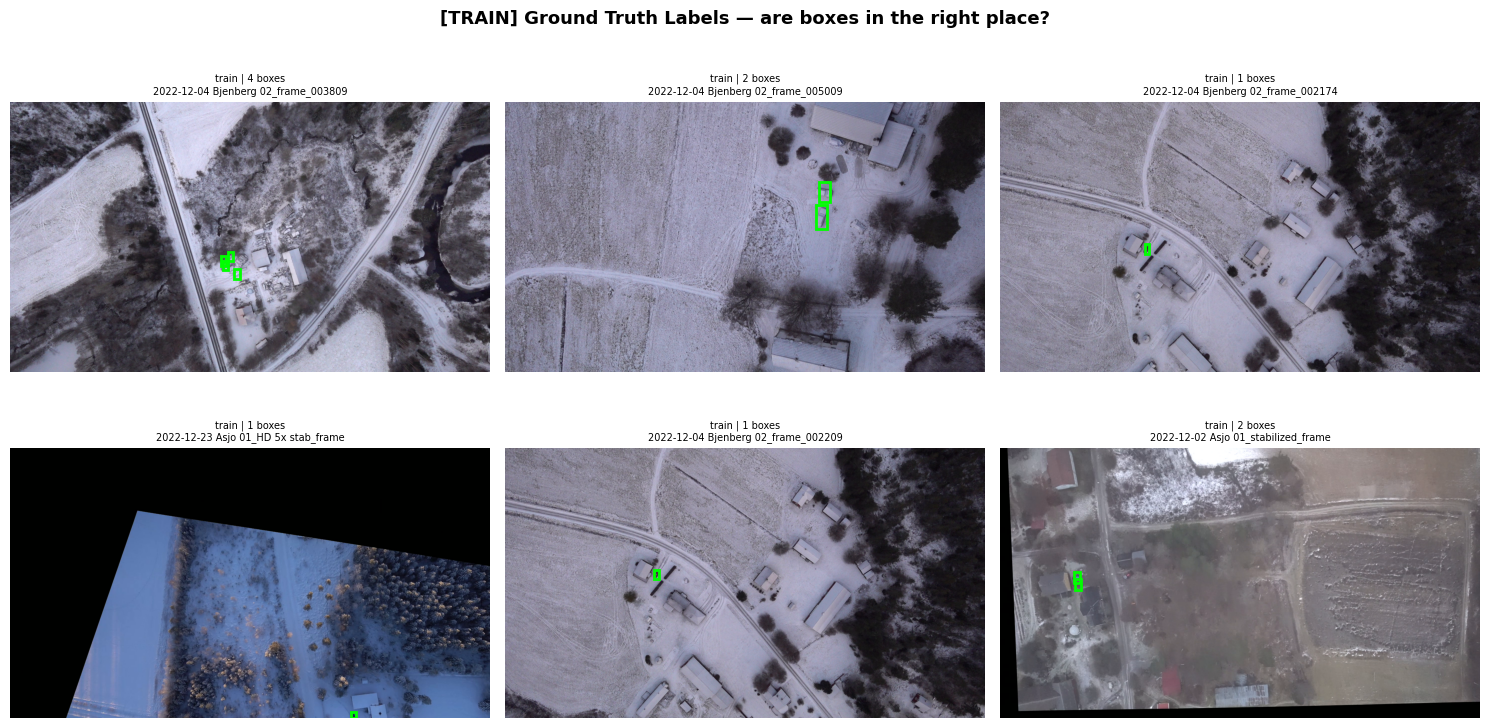

Saved: outputs\results\diag_gt_samples_train.png


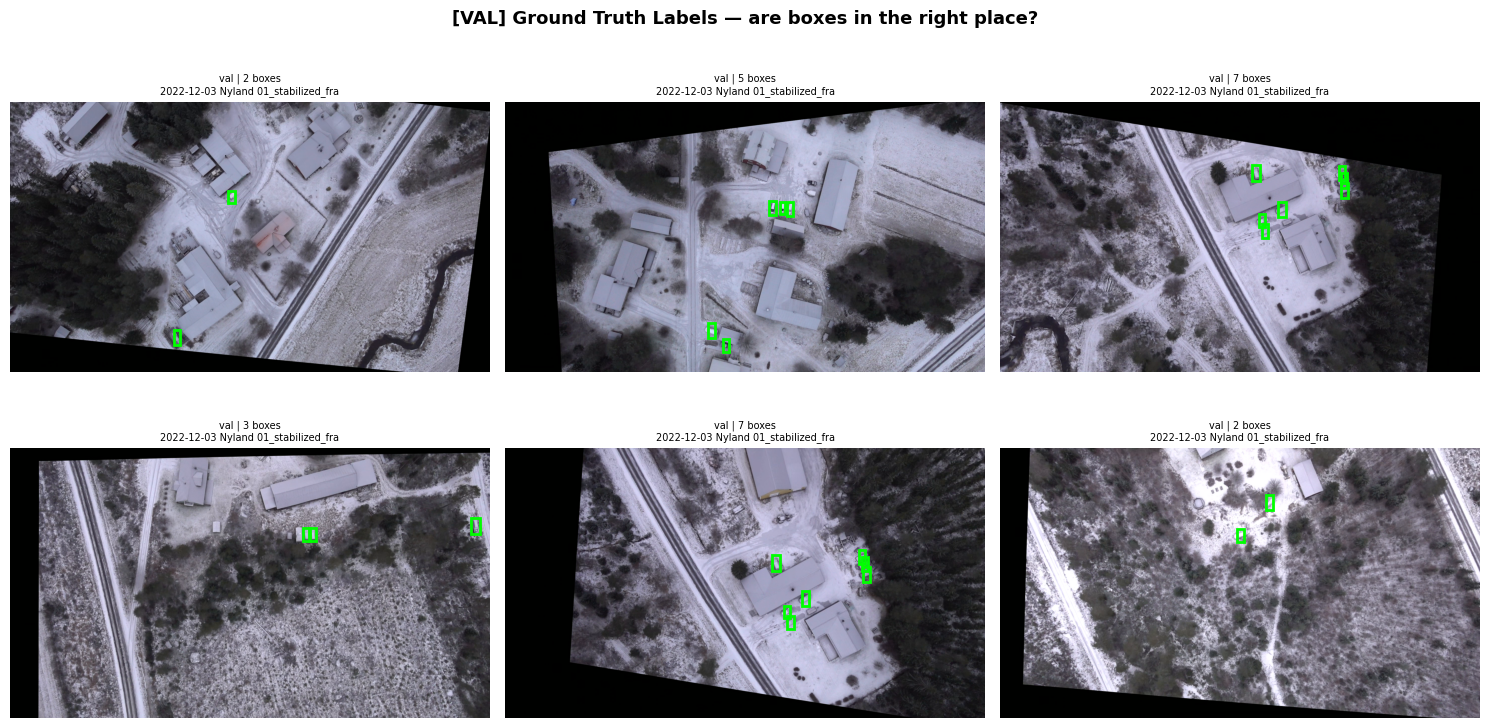

Saved: outputs\results\diag_gt_samples_val.png


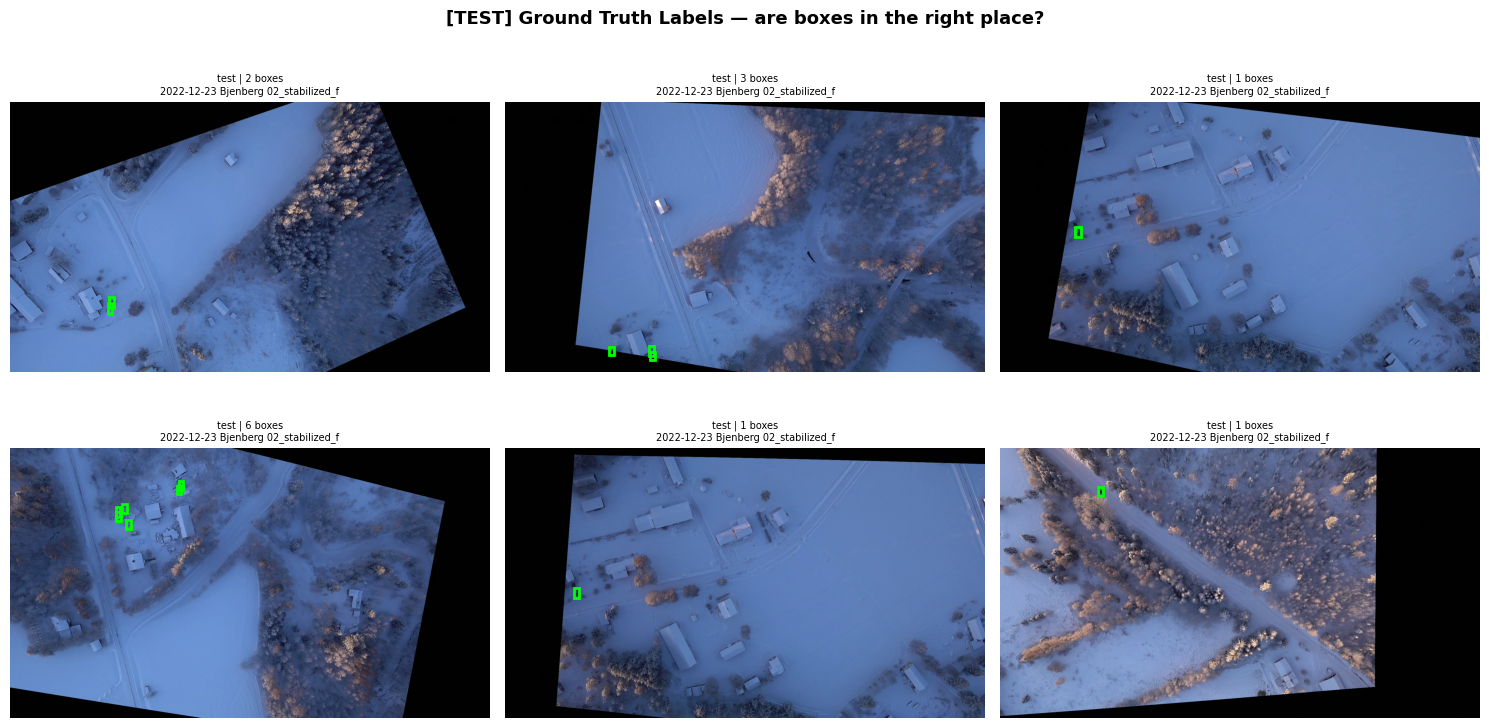

Saved: outputs\results\diag_gt_samples_test.png


In [7]:
def show_samples_with_gt(split, n=6, seed=42):
    img_dir = IMG_ROOT / split
    lbl_dir = LBL_ROOT / split
    
    images = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    rng    = np.random.default_rng(seed)
    
    # Prefer images that have annotations
    annotated = [p for p in images if (lbl_dir / (p.stem + '.txt')).exists()
                 and len((lbl_dir / (p.stem + '.txt')).read_text().strip()) > 0]
    
    pool  = annotated if len(annotated) >= n else images
    picks = list(rng.choice(pool, min(n, len(pool)), replace=False))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, img_path in enumerate(picks):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        
        axes[i].imshow(img)
        axes[i].set_title(img_path.name[:40], fontsize=7)
        axes[i].axis('off')
        
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        n_boxes  = 0
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, cx, cy, w, h = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (cx - w / 2) * W
                y1 = (cy - h / 2) * H
                rect = patches.Rectangle((x1, y1), w * W, h * H,
                                         linewidth=2, edgecolor='lime', facecolor='none')
                axes[i].add_patch(rect)
                n_boxes += 1
        
        axes[i].set_title(f'{split} | {n_boxes} boxes\n{img_path.name[:35]}', fontsize=7)
    
    plt.suptitle(f'[{split.upper()}] Ground Truth Labels — are boxes in the right place?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = RESULTS_DIR / f'diag_gt_samples_{split}.png'
    plt.savefig(str(out), dpi=120)
    plt.show()
    print(f'Saved: {out}')


for split in SPLITS:
    show_samples_with_gt(split)

## 6. Test Set Deep-Dive — The Smoking Gun
The val mAP is 0.33 but test is ~0. Let's find out exactly why.

In [8]:
# ── 6a. Check what % of test images are in the 'corrupt' list ────────────────
test_img_dir = IMG_ROOT / 'test'
test_lbl_dir = LBL_ROOT / 'test'

test_images = list(test_img_dir.glob('*.png')) + list(test_img_dir.glob('*.jpg'))

readable, unreadable, with_labels, without_labels, zero_bbox, has_bbox = 0, 0, 0, 0, 0, 0
sample_unreadable = []
sample_zero_bbox  = []

for p in test_images:
    img = cv2.imread(str(p))
    if img is None:
        unreadable += 1
        if len(sample_unreadable) < 5:
            sample_unreadable.append(p.name)
    else:
        readable += 1
    
    lbl = test_lbl_dir / (p.stem + '.txt')
    if lbl.exists():
        with_labels += 1
        lines = [l for l in lbl.read_text().strip().splitlines() if len(l.strip().split()) == 5]
        if len(lines) == 0:
            zero_bbox += 1
            if len(sample_zero_bbox) < 5:
                sample_zero_bbox.append(p.name)
        else:
            has_bbox += 1
    else:
        without_labels += 1

total = len(test_images)
print('TEST SET DEEP-DIVE')
print('=' * 55)
print(f'  Total test images    : {total}')
print(f'  Readable by OpenCV   : {readable}  ({100*readable/total:.1f}%)')
print(f'  UNREADABLE         : {unreadable}  ({100*unreadable/total:.1f}%)  ← these count as wrong predictions')
print(f'  Have a .txt label    : {with_labels}  ({100*with_labels/total:.1f}%)')
print(f'  Missing .txt label   : {without_labels}  ← PROBLEM: model evaluated without GT')
print(f'  Label exists but 0 bbox: {zero_bbox}  ← background images, OK if expected')
print(f'  Has ≥1 annotated bbox: {has_bbox}  ({100*has_bbox/total:.1f}%)')

if sample_unreadable:
    print(f'\n  Example unreadable files:')
    for f in sample_unreadable:
        print(f'    {f}')

if sample_zero_bbox:
    print(f'\n  Example zero-bbox label files:')
    for f in sample_zero_bbox:
        print(f'    {f}')

print('\n  DIAGNOSIS:')
if unreadable / total > 0.05:
    print(f'  {unreadable} corrupt images ({100*unreadable/total:.0f}%) in test set — this directly tanks mAP')
if without_labels > 0:
    print(f'  {without_labels} images have no label file — model has no GT to compare against')
if has_bbox / total < 0.5:
    print(f'  Only {100*has_bbox/total:.0f}% of test images have any annotation — evaluation is broken')
if unreadable == 0 and without_labels == 0 and has_bbox / total > 0.8:
    print(f'  Test images and labels look structurally OK — issue may be visual domain shift')

TEST SET DEEP-DIVE
  Total test images    : 1191
  Readable by OpenCV   : 1191  (100.0%)
  UNREADABLE         : 0  (0.0%)  ← these count as wrong predictions
  Have a .txt label    : 1191  (100.0%)
  Missing .txt label   : 0  ← PROBLEM: model evaluated without GT
  Label exists but 0 bbox: 0  ← background images, OK if expected
  Has ≥1 annotated bbox: 1191  (100.0%)

  DIAGNOSIS:
  Test images and labels look structurally OK — issue may be visual domain shift


In [9]:
# ── 6b. File naming check ─────────────────────────────────────────────────────
# YOLO pairs images to labels by replacing /images/ with /labels/ and extension with .txt
# A common bug: image is .jpg but label is .txt looked up from .png path (or vice versa)

print('FILE NAMING CONSISTENCY CHECK')
print('=' * 55)
for split in SPLITS:
    img_dir = IMG_ROOT / split
    lbl_dir = LBL_ROOT / split
    
    imgs = {p.stem: p.suffix for p in list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))}
    lbls = {p.stem for p in lbl_dir.glob('*.txt')}
    
    imgs_no_label = set(imgs.keys()) - lbls
    lbls_no_image = lbls - set(imgs.keys())
    
    print(f'\n[{split.upper()}]')
    print(f'  Image stems    : {len(imgs)}')
    print(f'  Label stems    : {len(lbls)}')
    print(f'  Images without matching .txt : {len(imgs_no_label)}')
    print(f'  .txt files without matching image : {len(lbls_no_image)}')
    
    if imgs_no_label:
        sample = list(imgs_no_label)[:3]
        print(f'Example images with no label: {sample}')
    if lbls_no_image:
        sample = list(lbls_no_image)[:3]
        print(f'Example orphan labels: {sample}')

FILE NAMING CONSISTENCY CHECK

[TRAIN]
  Image stems    : 6056
  Label stems    : 6056
  Images without matching .txt : 0
  .txt files without matching image : 0

[VAL]
  Image stems    : 1203
  Label stems    : 1203
  Images without matching .txt : 0
  .txt files without matching image : 0

[TEST]
  Image stems    : 1191
  Label stems    : 1191
  Images without matching .txt : 0
  .txt files without matching image : 0


## 7. Model Prediction vs GT on Test Images
Load the trained best.pt and see what it actually predicts on test images.
If predictions look reasonable but GT is wrong → label problem.
If predictions are garbage → model genuinely fails on this domain.

In [10]:
model_path = Path('outputs/results/v1/weights/best.pt')

if not model_path.exists():
    print(f'[skip] {model_path} not found - this notebook can run without a trained model.')
else:
    from ultralytics import YOLO
    model = YOLO(str(model_path))

    test_img_dir = IMG_ROOT / 'test'
    test_lbl_dir = LBL_ROOT / 'test'

    candidates = []
    for p in list(test_img_dir.glob('*.png')) + list(test_img_dir.glob('*.jpg')):
        img = cv2.imread(str(p))
        if img is None:
            continue
        lbl = test_lbl_dir / (p.stem + '.txt')
        if lbl.exists() and len(lbl.read_text().strip()) > 0:
            candidates.append(p)

    rng   = np.random.default_rng(42)
    picks = list(rng.choice(candidates, min(6, len(candidates)), replace=False))

    print(f'Running inference on {len(picks)} test images...')

    fig, axes = plt.subplots(len(picks), 2, figsize=(14, 4 * len(picks)))
    if len(picks) == 1:
        axes = [axes]

    for row, img_path in enumerate(picks):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        H, W    = img_rgb.shape[:2]

        ax_gt = axes[row][0]
        ax_gt.imshow(img_rgb)
        ax_gt.set_title(f'GT — {img_path.name[:40]}', fontsize=7)
        ax_gt.axis('off')

        lbl_path = test_lbl_dir / (img_path.stem + '.txt')
        n_gt = 0
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                _, cx, cy, w, h = [float(x) for x in parts]
                x1 = (cx - w/2) * W
                y1 = (cy - h/2) * H
                rect = patches.Rectangle((x1, y1), w*W, h*H,
                                          linewidth=2, edgecolor='lime', facecolor='none')
                ax_gt.add_patch(rect)
                n_gt += 1
        ax_gt.set_title(f'GT ({n_gt} boxes) | {img_path.name[:30]}', fontsize=7)

        ax_pred = axes[row][1]
        ax_pred.imshow(img_rgb)
        ax_pred.axis('off')

        results = model.predict(str(img_path), conf=0.1, verbose=False)
        boxes   = results[0].boxes
        n_pred  = 0
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf = float(box.conf[0])
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor='red', facecolor='none')
                ax_pred.add_patch(rect)
                ax_pred.text(x1, y1-4, f'{conf:.2f}', color='red', fontsize=7)
                n_pred += 1
        ax_pred.set_title(f'Pred ({n_pred} boxes, conf≥0.1)', fontsize=8)

    plt.suptitle('Ground Truth (green) vs Model Predictions (red) on TEST images',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out = RESULTS_DIR / 'diag_pred_vs_gt_test.png'
    plt.savefig(str(out), dpi=120)
    plt.show()
    print(f'Saved: {out}')

[skip] outputs\results\v1\weights\best.pt not found - this notebook can run without a trained model.


## 8. Summary Report

In [11]:
print('\n' + '='*70)
print('  DATA QUALITY DIAGNOSTIC SUMMARY')
print('='*70)

issues = []
ok     = []

for split in SPLITS:
    s = all_stats[split]
    im = img_stats[split]
    
    if s['missing_label_files'] > 0:
        issues.append(f'[{split}] {s["missing_label_files"]} images have NO label file')
    else:
        ok.append(f'[{split}] All images have label files')
    
    if s['corrupt_label_files'] > 0:
        issues.append(f'[{split}] {s["corrupt_label_files"]} CORRUPT label rows found')
    else:
        ok.append(f'[{split}] No corrupt label rows')
    
    if s['out_of_range_coords'] > 0:
        issues.append(f'[{split}] {s["out_of_range_coords"]} out-of-range bbox coordinates')
    else:
        ok.append(f'[{split}] All bbox coords in valid range [0,1]')
    
    if im['corrupt'] > 0:
        issues.append(f'[{split}] {im["corrupt"]} unreadable images')
    else:
        ok.append(f'[{split}] All sampled images are readable')

# Distribution comparison
train_bright = np.mean(img_stats['train']['mean_brightness']) if img_stats['train']['mean_brightness'] else 0
test_bright  = np.mean(img_stats['test']['mean_brightness'])  if img_stats['test']['mean_brightness']  else 0
bright_gap   = abs(train_bright - test_bright)

if bright_gap > 20:
    issues.append(f'DOMAIN SHIFT: Train brightness={train_bright:.1f} vs Test brightness={test_bright:.1f} — gap={bright_gap:.1f} (>20 is significant)')
else:
    ok.append(f'Brightness gap train vs test = {bright_gap:.1f} (within 20, acceptable)')

print('\n PASSING:')
for item in ok:
    print(f'     {item}')

print('\n PROBLEMS FOUND:')
if issues:
    for item in issues:
        print(f'     {item}')
else:
    print('     None found structurally — problem is likely VISUAL DOMAIN SHIFT')
    print('     Check the brightness/contrast plots and GT vs Pred images above')
    print('     Test frames may be from a different scene/condition than train')
print('='*70)


  DATA QUALITY DIAGNOSTIC SUMMARY

 PASSING:
     [train] All images have label files
     [train] No corrupt label rows
     [train] All bbox coords in valid range [0,1]
     [train] All sampled images are readable
     [val] All images have label files
     [val] No corrupt label rows
     [val] All bbox coords in valid range [0,1]
     [val] All sampled images are readable
     [test] All images have label files
     [test] No corrupt label rows
     [test] All bbox coords in valid range [0,1]
     [test] All sampled images are readable

 PROBLEMS FOUND:
     DOMAIN SHIFT: Train brightness=103.4 vs Test brightness=77.3 — gap=26.1 (>20 is significant)


## 9. Comprehensive Corruption Audit
Section 2 only sampled 200 images per split, so corrupt files easily slip through.
This section scans **every** image with stronger checks:

- `PIL.verify()` catches truncated/structurally-broken PNG headers that `cv2.imread` silently accepts.
- File-size check catches partial writes.
- Pixel-statistics check catches all-black / frozen / uniform frames (a common decord seek failure mode).
- Duplicate-frame detection (16×16 MD5 hash, grouped by sequence) catches decord random-access bugs where adjacent indices return the same buffer — a real risk for our train splits, especially `2022-12-23 Asjo 01_HD 5x stab`.

Results are written to `outputs/results/diag_corruption_report.json`.

In [12]:
# ── 9b. Full corruption scan (every image, no sampling) ─────────────────────
# What we look for:
#   - PIL.verify failure  -> truncated PNG header that cv2.imread silently accepts
#   - cv2 unreadable      -> total decode failure
#   - wrong shape         -> partial decode (not 1920x1080)
#   - tiny file size      -> partial write (1080p PNG should be > ~50KB)
#   - flat / black image  -> decord returned uniform buffer (frozen frame)
# We also collect a 16x16 MD5 of each image for the duplicate check in 9c.

from PIL import Image
import hashlib
import re
from collections import defaultdict, Counter
from time import time
import warnings
warnings.filterwarnings('ignore')

def scan_image(path):
    """Returns (issues_list, fsize, mean, std, content_hash)."""
    issues = []
    fsize = path.stat().st_size

    try:
        with Image.open(path) as im:
            im.verify()
    except Exception as e:
        return ([f'pil_verify_fail:{type(e).__name__}'], fsize, None, None, None)

    img = cv2.imread(str(path))
    if img is None:
        return (['cv2_unreadable'], fsize, None, None, None)

    h, w = img.shape[:2]
    if (w, h) != (1920, 1080):
        issues.append(f'wrong_shape:{w}x{h}')

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    m = float(gray.mean())
    s = float(gray.std())

    small = cv2.resize(img, (16, 16), interpolation=cv2.INTER_AREA)
    h_hex = hashlib.md5(small.tobytes()).hexdigest()

    if fsize < 50_000:
        issues.append(f'tiny_file:{fsize}B')
    if s < 1.0:
        issues.append(f'flat_image:std={s:.2f}')
    if m < 5.0:
        issues.append(f'all_black:mean={m:.1f}')
    if m > 250.0:
        issues.append(f'all_white:mean={m:.1f}')

    return (issues, fsize, m, s, h_hex)


report = {}
all_data = {}

for split in SPLITS:
    img_dir = IMG_ROOT / split
    images = sorted(list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg')))

    print(f'\n[{split.upper()}] scanning {len(images)} images...')
    t0 = time()

    bad = []
    data = []
    for p in images:
        issues, fsize, m, s, h_hex = scan_image(p)
        if issues:
            bad.append({'name': p.name, 'issues': issues, 'fsize': fsize, 'mean': m, 'std': s})
        data.append((p.name, h_hex, m, s))

    elapsed = time() - t0
    pct = 100 * len(bad) / max(1, len(images))
    print(f'  done in {elapsed:.1f}s | flagged {len(bad)} ({pct:.1f}%)')

    report[split] = bad
    all_data[split] = data


print('\n' + '=' * 65)
print('CORRUPTION ISSUE COUNTS BY SPLIT')
print('=' * 65)
for split in SPLITS:
    counter = Counter()
    for entry in report[split]:
        for tag in entry['issues']:
            kind = tag.split(':')[0]
            counter[kind] += 1

    total_flags = sum(counter.values())
    print(f'\n[{split.upper()}] {total_flags} total flags across {len(report[split])} files')
    if not counter:
        print('  (clean)')
    for kind, n in counter.most_common():
        print(f'  {kind:25s}: {n}')

    if report[split]:
        print(f'  First 5 flagged files:')
        for entry in report[split][:5]:
            print(f'    {entry["name"][:50]:50s} -> {entry["issues"]}')


[TRAIN] scanning 6056 images...


  done in 422.2s | flagged 0 (0.0%)

[VAL] scanning 1203 images...


  done in 78.8s | flagged 0 (0.0%)

[TEST] scanning 1191 images...


  done in 59.0s | flagged 0 (0.0%)

CORRUPTION ISSUE COUNTS BY SPLIT

[TRAIN] 0 total flags across 0 files
  (clean)

[VAL] 0 total flags across 0 files
  (clean)

[TEST] 0 total flags across 0 files
  (clean)


In [13]:
# ── 9c. Duplicate frame detection ───────────────────────────────────────────
# decord random-access seeking can return the same frame for adjacent indices on
# some codecs (notably H.264 with B-frames). Hash collisions WITHIN a sequence
# are the strongest evidence of this bug.
# We hash each image to a 16x16 thumbnail MD5 and group by hash within sequence.

print('DUPLICATE FRAME DETECTION')
print('=' * 65)

pat = re.compile(r'(.+?)_frame_(\d+)\.(?:png|jpg|jpeg)$', re.IGNORECASE)
dup_summary = {}

for split in SPLITS:
    by_hash = defaultdict(list)
    for name, h_hex, m, s in all_data[split]:
        if h_hex is None:
            continue
        match = pat.match(name)
        if not match:
            continue
        seq = match.group(1)
        idx = int(match.group(2))
        by_hash[h_hex].append((seq, idx, name))

    duplicates_within_seq = []
    duplicates_cross_seq = []
    for h_hex, entries in by_hash.items():
        if len(entries) < 2:
            continue
        seq_groups = defaultdict(list)
        for seq, idx, name in entries:
            seq_groups[seq].append((idx, name))
        for seq, items in seq_groups.items():
            if len(items) >= 2:
                duplicates_within_seq.append((seq, h_hex[:12], sorted(items)))
        if len(seq_groups) > 1:
            duplicates_cross_seq.append((h_hex[:12], dict(seq_groups)))

    n_dup_within = sum(len(items) for _, _, items in duplicates_within_seq)
    print(f'\n[{split.upper()}]')
    print(f'  Hash groups colliding within a sequence : {len(duplicates_within_seq)}')
    print(f'  Total frames duplicated within sequence : {n_dup_within}')
    print(f'  Hash groups colliding across sequences  : {len(duplicates_cross_seq)}')

    if duplicates_within_seq:
        print(f'  Suggests decord seek bug or genuine repeat in source video.')
        print(f'  Examples (first 5):')
        for seq, h_short, items in duplicates_within_seq[:5]:
            idxs = [i for i, _ in items][:8]
            print(f'    [{seq[:35]:35s}] hash={h_short} frames={idxs}')

    dup_summary[split] = {
        'within_seq_hash_groups': len(duplicates_within_seq),
        'within_seq_total_dup_frames': n_dup_within,
        'cross_seq_hash_groups': len(duplicates_cross_seq),
        'examples': duplicates_within_seq[:10],
    }

DUPLICATE FRAME DETECTION

[TRAIN]
  Hash groups colliding within a sequence : 0
  Total frames duplicated within sequence : 0
  Hash groups colliding across sequences  : 0

[VAL]
  Hash groups colliding within a sequence : 0
  Total frames duplicated within sequence : 0
  Hash groups colliding across sequences  : 0

[TEST]
  Hash groups colliding within a sequence : 0
  Total frames duplicated within sequence : 0
  Hash groups colliding across sequences  : 0


In [14]:
# ── 9d. Visualize worst offenders + save full report ─────────────────────────
import json

flat_pool = [(split, entry) for split in SPLITS for entry in report[split]]

if not flat_pool:
    print('No flagged images to visualize - corruption audit clean!')
else:
    priority = {'pil_verify_fail': 0, 'cv2_unreadable': 1, 'flat_image': 2,
                'all_black': 3, 'all_white': 3, 'tiny_file': 4, 'wrong_shape': 5}
    def rank(entry):
        kinds = [t.split(':')[0] for t in entry['issues']]
        return min(priority.get(k, 99) for k in kinds)
    flat_pool.sort(key=lambda x: rank(x[1]))

    show = flat_pool[:9]
    rows = (len(show) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
    axes = np.array(axes).flatten()

    for ax, (split, entry) in zip(axes, show):
        path = IMG_ROOT / split / entry['name']
        img = cv2.imread(str(path))
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.text(0.5, 0.5, 'UNREADABLE BY cv2', ha='center', va='center',
                    fontsize=14, color='red', transform=ax.transAxes)
        ax.set_title(f'[{split}] {entry["name"][:35]}\n{", ".join(entry["issues"])[:55]}',
                     fontsize=8)
        ax.axis('off')

    for ax in axes[len(show):]:
        ax.axis('off')

    plt.suptitle('Flagged images - worst offenders (first 9)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(Path(YOLO_ROOT).parent / 'results' / 'diag_corrupt_samples.png'), dpi=120)
    plt.show()
    print('Saved corrupt sample image grid.')


# Persist full report to JSON
results_dir = Path(YOLO_ROOT).parent / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
report_path = results_dir / 'diag_corruption_report.json'

serializable = {
    'flagged_per_split': {
        split: [
            {'name': e['name'], 'issues': e['issues'], 'fsize': e['fsize'],
             'mean': e['mean'], 'std': e['std']}
            for e in report[split]
        ]
        for split in SPLITS
    },
    'duplicate_summary': {
        split: {
            'within_seq_hash_groups': dup_summary[split]['within_seq_hash_groups'],
            'within_seq_total_dup_frames': dup_summary[split]['within_seq_total_dup_frames'],
            'cross_seq_hash_groups': dup_summary[split]['cross_seq_hash_groups'],
            'examples': [
                {'sequence': seq, 'hash': h_short, 'frames': [n for _, n in items[:10]]}
                for seq, h_short, items in dup_summary[split]['examples']
            ],
        } for split in SPLITS
    },
    'totals': {
        split: {
            'scanned': len(all_data[split]),
            'flagged': len(report[split]),
            'flagged_pct': round(100 * len(report[split]) / max(1, len(all_data[split])), 2),
        } for split in SPLITS
    },
}

with open(report_path, 'w') as f:
    json.dump(serializable, f, indent=2)
print(f'\nSaved full report -> {report_path}')

print('\nNext steps if corruption is found:')
print('  1. Duplicate frames in train  -> likely decord random-access bug;')
print('     try sequential read or fall back to cv2.VideoCapture for those sequences.')
print('  2. pil_verify_fail            -> PNG is structurally broken; re-extract.')
print('  3. all_black / flat_image     -> video had a title card / fade; verify XML annotations')
print('     are not labelling those frames.')
print('  4. wrong_shape                -> partial decode; re-extract or skip.')
print('  5. tiny_file                  -> partial write; re-extract.')

No flagged images to visualize - corruption audit clean!

Saved full report -> outputs\results\diag_corruption_report.json

Next steps if corruption is found:
  1. Duplicate frames in train  -> likely decord random-access bug;
     try sequential read or fall back to cv2.VideoCapture for those sequences.
  2. pil_verify_fail            -> PNG is structurally broken; re-extract.
  3. all_black / flat_image     -> video had a title card / fade; verify XML annotations
     are not labelling those frames.
  4. wrong_shape                -> partial decode; re-extract or skip.
  5. tiny_file                  -> partial write; re-extract.
